In [1]:
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
path = kagglehub.dataset_download("muhammetvarl/splicejunction-gene-sequences-dataset")
df = pd.read_csv(os.path.join(path, "dna.csv"))

print(f"Shape: {df.shape}")
df.head()

C:\Users\Pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shape: (3186, 181)


,A0,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A171,A172,A173,A174,A175,A176,A177,A178,A179,class
0,0,1,0,0,0,0,1,0,0,0,...,1,0,0,0,0,1,1,0,0,3
1,0,0,1,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,1,0,3
2,0,0,1,0,0,1,0,1,0,0,...,0,1,0,0,0,1,0,0,1,3
3,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,1,1
4,0,1,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,1,0,0,2


C:\Users\Pc\AppData\Local\Temp\ipykernel_17484\4180819834.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["class_name"] = df["class"].map(class_labels)
C:\Users\Pc\AppData\Local\Temp\ipykernel_17484\4180819834.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class_name", data=df, palette="Blues", ax=axes[0])


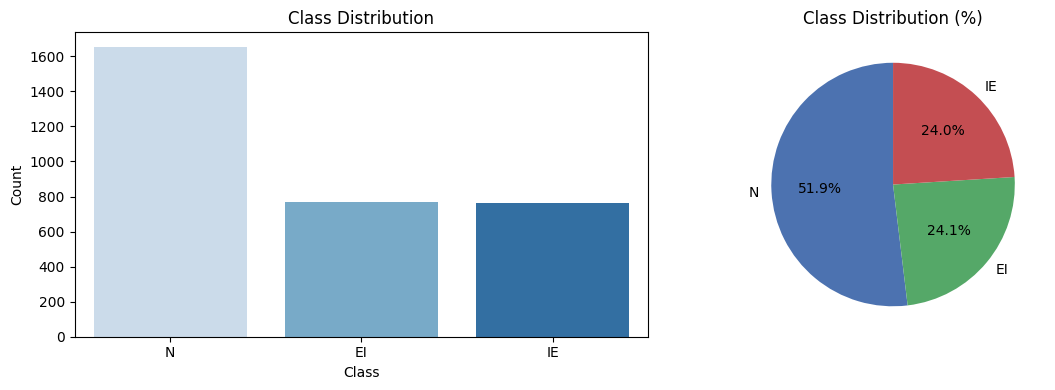

In [2]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
class_labels = {1: "EI", 2: "IE", 3: "N"}
df["class_name"] = df["class"].map(class_labels)

sns.countplot(x="class_name", data=df, palette="Blues", ax=axes[0])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# Pie chart
df["class_name"].value_counts().plot.pie(
    autopct="%1.1f%%", colors=["#4C72B0", "#55A868", "#C44E52"],
    ax=axes[1], startangle=90
)
axes[1].set_title("Class Distribution (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [3]:
# Feature statistics
print("=== Dataset Info ===")
print(f"Total samples: {len(df)}")
print(f"Total features: {df.shape[1] - 2}")  # excluding class and class_name
print(f"\nClass distribution:")
print(df["class_name"].value_counts())

print(f"\n=== Feature Value Counts ===")
# How many features are mostly 0 vs mostly 1
feature_means = df.drop(["class", "class_name"], axis=1).mean()
print(f"Features with mean > 0.5 (mostly 1): {(feature_means > 0.5).sum()}")
print(f"Features with mean < 0.5 (mostly 0): {(feature_means < 0.5).sum()}")

# Feature variance — low variance features carry less info
low_var = (df.drop(["class", "class_name"], axis=1).var() < 0.05).sum()
print(f"\nLow variance features (var < 0.05): {low_var}")

=== Dataset Info ===
Total samples: 3186
Total features: 180

Class distribution:
class_name
N     1654
EI     767
IE     765
Name: count, dtype: int64

=== Feature Value Counts ===
Features with mean > 0.5 (mostly 1): 2
Features with mean < 0.5 (mostly 0): 178

Low variance features (var < 0.05): 0
